# Ames Housing Dataset

## About Dataset
The Ames Housing Dataset is a well-known dataset in the field of machine learning and data analysis. It contains various features and attributes of residential homes in Ames, Iowa, USA. The dataset is often used for regression tasks, particularly for predicting housing prices.

### Key Details:
- **Number of Instances**: The dataset consists of 2,930 instances or observations.
- **Number of Features**: There are 79 different features or variables that describe various aspects of the residential properties.
- **Target Variable**: The target variable in the dataset is `SalePrice`, representing the sale price of the houses.
- **Data Types**:  
  - The features include both numerical and categorical variables.
  - They cover a wide range of aspects such as lot size, number of rooms, location, construction quality, and more.

### Applications:
The Ames Housing Dataset is widely used in the machine learning community for:
- **Regression Modeling**: Predicting house prices based on property features.
- **Feature Engineering**: Developing and testing new techniques to handle numerical and categorical data.
- **Predictive Analytics**: Analyzing and forecasting trends in the real estate domain.

This dataset serves as a valuable resource for exploring and applying machine learning algorithms to real-world problems related to housing prices.


# STEP 1: IMPORT LIBRARIES AND SETUP

In [ ]:
# Install any packages not included in the SageMaker environment
!pip install seaborn -q

In [1]:
# Standard Libraries
import os
import time
import logging

# Data Handling & Visualization Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Scikit-learn Libraries for Model Building & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score
)

# AWS & SageMaker Libraries for Model Training and Deployment
import boto3
import sagemaker
from sagemaker import Session, get_execution_role
from sagemaker.estimator import Estimator
from sagemaker.amazon.linear_learner import LinearLearner  # SageMaker's built-in Linear Learner algorithm
from sagemaker.inputs import TrainingInput
from sagemaker.predictor import Predictor
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import JSONDeserializer

# Additional Libraries
from botocore.exceptions import ClientError
from typing import Any, List, Union

# Logger Setup
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Global Variables
file_path = "ames_housing_preprocessed.csv"  # Preprocessed dataset from DATA/LINEAR_LEARNER lab
original_target_col = "SalePrice"    # Name of the original target variable in the dataset


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pydantic/_internal/_fields.py:192: UserWarning: Field name "json" in "MonitoringDatasetFormat" shadows an attribute in parent "Base"
  warnings.warn(


[02/03/25 11:55:03] INFO     Found credentials from IAM Role:                                   ]8;id=435132;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=815926;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


# STEP 2: LOAD PREPROCESSED DATA

This notebook uses the preprocessed Ames Housing dataset produced by the
DATA/LINEAR_LEARNER lab. That lab handles all data cleaning, missing value
imputation, outlier removal, and categorical encoding.

**Before running this notebook**, copy `ames_housing_preprocessed.csv` from
the `DATA/LINEAR_LEARNER/` directory into this notebook's directory.

In [ ]:
def load_preprocessed_data(filepath):
    """
    Load the preprocessed Ames Housing dataset.

    This file was produced by the DATA/LINEAR_LEARNER preprocessing lab
    and contains all features already cleaned and encoded.
    """
    df = pd.read_csv(filepath)
    print(f"Loaded preprocessed data: {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"\nFirst 5 rows:")
    display(df.head())
    return df

df = load_preprocessed_data(file_path)


# STEP 3: CREATE MULTI CLASS TARGETS

In [8]:
# Define the number of quantile-based categories for 'SalePrice'.
num_classes = 3

# Convert 'SalePrice' into quantile-based categories.
# 'pd.qcut' divides the data into 'num_classes' groups with an equal number of observations.
# 'labels=False' assigns integer labels (0, 1, 2) corresponding to increasing price levels.
df["SalePriceClass"] = pd.qcut(df[original_target_col], q=num_classes, labels=False)

# Remove the original continuous 'SalePrice' column to keep only the categorical version.
df.drop(columns=[original_target_col], inplace=True)

# Update the target column reference to reflect the new categorical variable.
target_col = "SalePriceClass"

# Print the distribution of the new target classes to verify the quantile split.
class_counts = df[target_col].value_counts().sort_index()  # Sort by category label
class_percentages = (class_counts / len(df)) * 100  # Convert to percentage

print("\nTarget Distribution:")
for category, count in class_counts.items():
    print(f"Class {category}: {count} samples ({class_percentages[category]:.2f}%)")

# Print a sample of the updated DataFrame (first 5 rows)
print("\nSample of the Modified Dataset:")
print(df.head())  # Display the first few rows



Target Distribution:
Class 0: 981 samples (33.54%)
Class 1: 977 samples (33.40%)
Class 2: 967 samples (33.06%)

Sample of the Modified Dataset:
   Order        PID  MS SubClass  Lot Frontage  Lot Area  Overall Qual  \
0      1  526301100           20         141.0     31770             6   
1      2  526350040           20          80.0     11622             5   
2      3  526351010           20          81.0     14267             6   
3      4  526353030           20          93.0     11160             7   
4      5  527105010           60          74.0     13830             5   

   Overall Cond  Year Built  Year Remod/Add  Mas Vnr Area  ...  Sale Type_New  \
0             5        1960            1960         112.0  ...              0   
1             6        1961            1961           0.0  ...              0   
2             6        1958            1958         108.0  ...              0   
3             5        1968            1968           0.0  ...              0   
4    

# STEP 4: SPLIT THE DATA INTO TRAIN AND VALIDATION

In [9]:
# Separate the features (X) and the target variable (y).
# X contains all columns except the target column.
# y contains only the target column.
X = df.drop(columns=[target_col])  # Features (predictor variables)
y = df[target_col]  # Target variable

# Split the data into training and validation sets.
# 'test_size=0.2' means 20% of the data is reserved for validation, and 80% for training.
# 'random_state=42' ensures that the split remains the same each time the code is run.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the training and validation sets to confirm successful splitting.
print(f"Training set: Features {X_train.shape}, Target {y_train.shape}")
print(f"Validation set: Features {X_val.shape}, Target {y_val.shape}")


Training set: Features (2340, 203), Target (2340,)
Validation set: Features (585, 203), Target (585,)


# STEP 5: PREPARE FILES AND SET UP SAGEMAKER SESSION

In [10]:
# Initialize a SageMaker session
sagemaker_session = sagemaker.Session()

# Get IAM execution role required for AWS SageMaker
role = get_execution_role()

# Define S3 bucket, AWS region, and dataset storage location
bucket = sagemaker_session.default_bucket()  # Default bucket assigned by SageMaker
region = sagemaker_session.boto_region_name  # AWS region for the session
prefix = "sagemaker/multiclass-ames-housing"  # S3 folder to store data

# Combine target labels (y) with features (X) for training and validation sets
train_data = pd.concat([y_train, X_train], axis=1)
validation_data = pd.concat([y_val, X_val], axis=1)

# Check for missing values and warn if detected
if train_data.isnull().values.any() or validation_data.isnull().values.any():
    print("Warning: Missing values detected! Consider handling them before training.")

# Check for class imbalance (if any class occupies more than 75% of the dataset)
train_class_distribution = y_train.value_counts(normalize=True)
val_class_distribution = y_val.value_counts(normalize=True)

if train_class_distribution.max() > 0.75 or val_class_distribution.max() > 0.75:
    print("Warning: Class imbalance detected. Consider balancing the dataset.")

# Define filenames for local storage
train_file = "ames_train_multiclass.csv"
validation_file = "ames_validation_multiclass.csv"

# Save training and validation datasets as CSV files (without headers and index)
train_data.to_csv(train_file, index=False, header=False)
validation_data.to_csv(validation_file, index=False, header=False)

# Upload datasets to S3 and store the generated S3 paths
train_uri = sagemaker_session.upload_data(path=train_file, bucket=bucket, key_prefix=prefix)
validation_uri = sagemaker_session.upload_data(path=validation_file, bucket=bucket, key_prefix=prefix)

# Print S3 paths of uploaded datasets
print(f"Training data uploaded to: {train_uri}")
print(f"Validation data uploaded to: {validation_uri}")


[02/03/25 11:55:04] INFO     Found credentials from IAM Role:                                   ]8;id=119567;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=272262;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

[02/03/25 11:55:05] INFO     Found credentials from IAM Role:                                   ]8;id=297326;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=681464;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

Training data uploaded to: s3://sagemaker-us-east-1-785881939712/sagemaker/multiclass-ames-housing/ames_train_multiclass.csv
Validation data uploaded to: s3://sagemaker-us-east-1-785881939712/sagemaker/multiclass-ames-housing/ames_validation_multiclass.csv


# STEP 6: TRAIN THE LINEAR LEARNER MODEL (MULTI CLASSIFICATION)

In [11]:
"""
This script sets up and launches an AWS SageMaker training job using the Linear Learner algorithm for multiclass classification.
It retrieves the appropriate container image URI, configures the estimator with the necessary hyperparameters, 
prepares the training and validation data from S3, and then initiates the training job.
"""

# Retrieve the container image URI for the Linear Learner algorithm in the specified region.
# This ensures we use the correct version of the image as defined by the latest SageMaker guidelines.
container = sagemaker.image_uris.retrieve(
    framework="linear-learner",
    region=region  # AWS region, e.g., 'us-west-2'
)

# Instantiate the SageMaker Estimator for the Linear Learner model with multiclass settings.
# The Estimator encapsulates configuration details such as the container image, compute resources, and output path.
linear_learner = Estimator(
    image_uri=container,                        # The container image for Linear Learner.
    role=role,                                  # The execution role granting SageMaker access to AWS resources.
    instance_count=1,                           # Number of instances for training.
    instance_type='ml.m5.large',                # Instance type chosen based on resource requirements.
    output_path=f's3://{bucket}/{prefix}/output',# S3 location for storing model artifacts after training.
    sagemaker_session=sagemaker_session         # The SageMaker session managing the training job.
)

# Determine the number of features in the training data.
# This value is used to set the 'feature_dim' hyperparameter, indicating the number of input features.
num_features = X.shape[1]

# Set hyperparameters for the Linear Learner model.
# - feature_dim: Number of input features.
# - predictor_type: Set to 'multiclass_classifier' to handle multiclass classification.
# - mini_batch_size: Specifies the number of samples per training mini-batch.
# - num_classes: Specifies the total number of target classes.
linear_learner.set_hyperparameters(
    feature_dim=num_features,
    predictor_type='multiclass_classifier',
    mini_batch_size=32,
    num_classes=num_classes  # Number of target classes (e.g., 0, 1, 2)
)

# Create TrainingInput objects for both training and validation datasets.
# Each TrainingInput points to an S3 location containing CSV data.
# The 'content_type' "text/csv" indicates the format of the input files.
train_input = TrainingInput(s3_data=train_uri, content_type="text/csv")
validation_input = TrainingInput(s3_data=validation_uri, content_type="text/csv")

# Start the model training process by launching a training job on SageMaker.
# The 'fit' method is called with a dictionary that specifies the training and validation data.
linear_learner.fit({'train': train_input, 'validation': validation_input})

# Inform the user that the model training has been initiated.
print("Model training complete!")


[02/03/25 11:55:06] INFO     Same images used for training and inference. Defaulting to image     ]8;id=177449;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py\image_uris.py]8;;\:]8;id=347112;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py#391\391]8;;\
                             scope: inference.                                                                     

                    INFO     Ignoring unnecessary instance type: None.                            ]8;id=880352;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py\image_uris.py]8;;\:]8;id=768624;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py#528\528]8;;\

                    INFO     Found credentials from IAM Role:                                   ]8;id=178135;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=595930;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

                    INFO     SageMaker Python SDK will collect telemetry to help us better  ]8;id=367359;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=198135;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py#91\91]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#confi                        
                             guring-and-using-defaults-with-the-sagemaker-python-sdk.                              

                    INFO     Creating training-job with name:                                       ]8;id=552639;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=946098;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#1042\1042]8;;\
                             linear-learner-2025-02-03-11-55-06-550                                                

2025-02-03 11:55:07 Starting - Starting the training job...
..25-02-03 11:55:21 Starting - Preparing the instances for training.
..25-02-03 11:55:47 Downloading - Downloading input data.
.....02-03 11:56:27 Downloading - Downloading the training image.
Docker entrypoint called with argument(s): trainmpleted. Training in progress..
Running default environment configuration script
[02/03/2025 11:57:43 INFO 139928951965504] Reading default configuration from /opt/amazon/lib/python3.8/site-packages/algorithm/resources/default-input.json: {'mini_batch_size': '1000', 'epochs': '15', 'feature_dim': 'auto', 'use_bias': 'true', 'binary_classifier_model_selection_criteria': 'accuracy', 'f_beta': '1.0', 'target_recall': '0.8', 'target_precision': '0.8', 'num_models': 'auto', 'num_calibration_samples': '10000000', 'init_method': 'uniform', 'init_scale': '0.07', 'init_sigma': '0.01', 'init_bias': '0.0', 'optimizer': 'auto', 'loss': 'auto', 'margin': '1.0', 'quantile': '0.5', 'loss_insensitivity': '

# STEP 7: DEPLOY THE MODEL

In [12]:
session = Session()                 # High-level SageMaker session
sm_client = boto3.client("sagemaker")
endpoint_name = "multi-learner-endpoint"

# -----------------------------------------------------------------------------
# 1. Use built-in waiter for InService (optional, but handy for waiting on creation)
# -----------------------------------------------------------------------------
endpoint_in_service_waiter = sm_client.get_waiter('endpoint_in_service')

def delete_endpoint_and_config(endpoint_name: str, wait_for_deletion: bool = True) -> None:
    """
    Deletes an endpoint and its corresponding endpoint configuration (if they exist).
    Optionally polls until resources are deleted.
    """
    # 1. Delete endpoint (if it exists).
    try:
        endpoint_desc = sm_client.describe_endpoint(EndpointName=endpoint_name)
        endpoint_status = endpoint_desc["EndpointStatus"]

        # If the endpoint is Creating or Updating, wait for it to become InService before deleting.
        if endpoint_status in ("Creating", "Updating"):
            logger.info(f"Endpoint '{endpoint_name}' is in '{endpoint_status}' state. Waiting before delete.")
            endpoint_in_service_waiter.wait(EndpointName=endpoint_name)  # Waits until 'InService'
        
        # Now delete
        logger.info(f"Deleting endpoint: {endpoint_name}")
        sm_client.delete_endpoint(EndpointName=endpoint_name)

    except ClientError as e:
        # If the endpoint was never found, ignore the error. Otherwise, re-raise.
        if e.response['Error']['Code'] == 'ValidationException' and "Could not find" in e.response['Error']['Message']:
            logger.info(f"Endpoint '{endpoint_name}' does not exist or has already been deleted.")
        else:
            raise e

    # 2. Delete endpoint config (if it exists).
    try:
        sm_client.describe_endpoint_config(EndpointConfigName=endpoint_name)
        logger.info(f"Deleting endpoint configuration: {endpoint_name}")
        sm_client.delete_endpoint_config(EndpointConfigName=endpoint_name)
    except ClientError as e:
        if e.response['Error']['Code'] == 'ValidationException' and "Could not find" in e.response['Error']['Message']:
            logger.info(f"Endpoint config '{endpoint_name}' does not exist or has already been deleted.")
        else:
            raise e

    # 3. Optionally poll for deletion. (There's no built-in waiter for deletion.)
    #    Below is a simple polling strategy for demonstration.
    if wait_for_deletion:
        logger.info("Waiting for endpoint & configuration to be deleted...")
        for _ in range(30):
            endpoint_exists = True
            endpoint_config_exists = True

            # Check endpoint
            try:
                sm_client.describe_endpoint(EndpointName=endpoint_name)
            except ClientError as e:
                if "Could not find" in e.response["Error"]["Message"]:
                    endpoint_exists = False

            # Check endpoint config
            try:
                sm_client.describe_endpoint_config(EndpointConfigName=endpoint_name)
            except ClientError as e:
                if "Could not find" in e.response["Error"]["Message"]:
                    endpoint_config_exists = False

            if not endpoint_exists and not endpoint_config_exists:
                logger.info("Endpoint and endpoint config fully deleted.")
                break

            logger.info("Endpoint or endpoint config still deleting... sleeping 10s.")
            time.sleep(10)
        else:
            logger.warning("Endpoint or endpoint config not fully deleted after 30 checks.")

def delete_model(model_name: str, wait_for_deletion: bool = True) -> None:
    """
    Deletes a SageMaker model if it exists. Optionally waits until it disappears.
    """
    try:
        sm_client.describe_model(ModelName=model_name)
        logger.info(f"Deleting model: {model_name}")
        sm_client.delete_model(ModelName=model_name)
    except ClientError as e:
        if "Could not find" in e.response["Error"]["Message"]:
            logger.info(f"Model '{model_name}' does not exist or is already deleted.")
        else:
            raise e

    if wait_for_deletion:
        # There's no official 'model deleted' waiter, so we poll:
        for _ in range(20):
            try:
                sm_client.describe_model(ModelName=model_name)
                logger.info("Model still deleting... sleeping 5s.")
                time.sleep(5)
            except ClientError as e:
                if "Could not find" in e.response["Error"]["Message"]:
                    logger.info("Model fully deleted.")
                    break
        else:
            logger.warning("Model was not deleted after waiting.")


delete_endpoint_and_config(endpoint_name)
# If your model is also named the same, you might do:
# delete_model(endpoint_name)

predictor = linear_learner.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large",
    endpoint_name=endpoint_name
)

predictor.serializer = CSVSerializer()
predictor.deserializer = JSONDeserializer()

logger.info(f"Endpoint '{endpoint_name}' deployed successfully and ready for inference.")


[02/03/25 11:58:54] INFO     Deleting endpoint: multi-learner-endpoint                             ]8;id=394431;file:///tmp/ipykernel_28569/2293413147.py\2293413147.py]8;;\:]8;id=852844;file:///tmp/ipykernel_28569/2293413147.py#26\26]8;;\

[02/03/25 11:58:55] INFO     Deleting endpoint configuration: multi-learner-endpoint               ]8;id=905167;file:///tmp/ipykernel_28569/2293413147.py\2293413147.py]8;;\:]8;id=46794;file:///tmp/ipykernel_28569/2293413147.py#39\39]8;;\

                    INFO     Waiting for endpoint & configuration to be deleted...                 ]8;id=839450;file:///tmp/ipykernel_28569/2293413147.py\2293413147.py]8;;\:]8;id=391276;file:///tmp/ipykernel_28569/2293413147.py#50\50]8;;\

                    INFO     Endpoint or endpoint config still deleting... sleeping 10s.           ]8;id=10721;file:///tmp/ipykernel_28569/2293413147.py\2293413147.py]8;;\:]8;id=891239;file:///tmp/ipykernel_28569/2293413147.py#73\73]8;;\

[02/03/25 11:59:05] INFO     Endpoint and endpoint config fully deleted.                           ]8;id=912938;file:///tmp/ipykernel_28569/2293413147.py\2293413147.py]8;;\:]8;id=483676;file:///tmp/ipykernel_28569/2293413147.py#70\70]8;;\

                    INFO     Creating model with name: linear-learner-2025-02-03-11-59-05-742       ]8;id=347642;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=546646;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#4094\4094]8;;\

[02/03/25 11:59:06] INFO     Creating endpoint-config with name multi-learner-endpoint              ]8;id=43195;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=995345;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#5889\5889]8;;\

                    INFO     Creating endpoint with name multi-learner-endpoint                     ]8;id=480124;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=487871;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#4711\4711]8;;\

-------!

[02/03/25 12:03:07] INFO     Endpoint 'multi-learner-endpoint' deployed successfully and ready    ]8;id=638964;file:///tmp/ipykernel_28569/2293413147.py\2293413147.py]8;;\:]8;id=793512;file:///tmp/ipykernel_28569/2293413147.py#120\120]8;;\
                             for inference.                                                                        

# STEP 8: EVALUATE THE DEPLOYED MODEL


Evaluation Metrics:
  Accuracy:  0.8410
  Precision: 0.8391
  Recall:    0.8410
  F1 Score:  0.8395

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       196
           1       0.79      0.73      0.76       196
           2       0.87      0.91      0.89       193

    accuracy                           0.84       585
   macro avg       0.84      0.84      0.84       585
weighted avg       0.84      0.84      0.84       585

Confusion Matrix (Raw Values):
[[174  22   0]
 [ 26 143  27]
 [  1  17 175]]


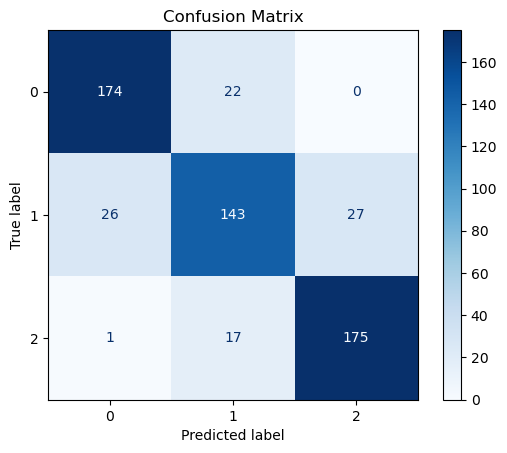

{'Accuracy': 0.841025641025641, 'Precision': 0.8391019010052555, 'Recall': 0.841025641025641, 'F1 Score': 0.8395171260784315}


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sagemaker.serializers import CSVSerializer

def evaluate_deployed_classifier_advanced(predictor, X_val, y_val, average='weighted'):
    """
    Evaluate a deployed SageMaker classification model on a validation set with detailed metrics.

    This function:
    - Sends validation data to the deployed model.
    - Extracts predicted probabilities from the response.
    - Assigns predicted labels using argmax for multiclass classification.
    - Computes Accuracy, Precision, Recall, and F1 Score.
    - Displays a classification report and confusion matrix.

    Parameters:
      predictor (SageMaker Predictor): The deployed model's predictor.
      X_val (pd.DataFrame): Feature matrix for validation.
      y_val (pd.Series): True labels for validation.
      average (str, optional): The averaging method for precision, recall, and F1 score. Defaults to 'weighted'.

    Returns:
      dict: A dictionary containing evaluation metrics.
    """
    
    # Configure the predictor to use CSV for input serialization
    predictor.serializer = CSVSerializer()

    # Convert validation features to array
    X_test = X_val.values.astype(np.float64)

    # Get predictions from the deployed model
    predictions = predictor.predict(X_test)

    # Ensure predictions have the expected format
    try:
        predicted_probs = np.array([result["score"] for result in predictions["predictions"]])
    except (KeyError, TypeError):
        raise ValueError("Unexpected prediction format. Ensure the model outputs probability distributions.")

    # Convert probabilities to class labels (Multiclass Classification)
    predicted_labels = np.argmax(predicted_probs, axis=1)

    # Compute evaluation metrics
    acc = accuracy_score(y_val, predicted_labels)
    prec = precision_score(y_val, predicted_labels, average=average, zero_division=0)
    rec = recall_score(y_val, predicted_labels, average=average, zero_division=0)
    f1 = f1_score(y_val, predicted_labels, average=average, zero_division=0)

    # Display results
    print("\nEvaluation Metrics:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}\n")

    # Print a detailed classification report
    print("Classification Report:")
    print(classification_report(y_val, predicted_labels, zero_division=0))

    # Compute the confusion matrix
    cm = confusion_matrix(y_val, predicted_labels)
    print("Confusion Matrix (Raw Values):")
    print(cm)

    # Display the confusion matrix as a heatmap
    unique_labels = np.unique(np.concatenate((y_val, predicted_labels)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

    # Return computed metrics
    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    }

metrics = evaluate_deployed_classifier_advanced(predictor, X_val, y_val)
print(metrics)


# STEP 9: QUERY THE DEPLOYED ENDPOINT WITH TEST DATA

In [ ]:
def query_test_predictions(predictor, X_val, y_val, n_samples=5):
    """
    Query the deployed endpoint with test data and display results as a
    formatted DataFrame table with class score charts and accuracy summary.

    Parameters:
        predictor: The SageMaker Predictor object.
        X_val (pd.DataFrame): Validation features.
        y_val (pd.Series): True target values.
        n_samples (int): Number of samples to query.
    """
    label_map = {0: "Low", 1: "Medium", 2: "High"}

    # Select the first n rows from the validation set
    sample_data = X_val.head(n_samples)
    input_data = sample_data.values.astype(np.float64)

    # Request predictions from the deployed endpoint
    predictions = predictor.predict(input_data)

    if "predictions" not in predictions:
        print("No 'predictions' key found in the response:", predictions)
        return

    # Extract scores and compute predicted classes
    all_scores = [result["score"] for result in predictions["predictions"]]
    predicted_classes = [int(np.argmax(scores)) for scores in all_scores]
    actual_classes = y_val.loc[sample_data.index].tolist()
    confidences = [float(max(scores)) for scores in all_scores]
    results = ["CORRECT" if p == a else "INCORRECT" for p, a in zip(predicted_classes, actual_classes)]

    # Build a results DataFrame
    results_df = pd.DataFrame({
        "Sample": [f"Row {i}" for i in range(1, n_samples + 1)],
        "Predicted": [f"{c} ({label_map[c]})" for c in predicted_classes],
        "Actual": [f"{a} ({label_map[a]})" for a in actual_classes],
        "Confidence": [f"{c:.4f}" for c in confidences],
        "Result": results
    })

    print("\nTest Predictions on 5 Validation Samples:")
    display(results_df)

    # Accuracy summary
    n_correct = results.count("CORRECT")
    print(f"\nAccuracy: {n_correct} of {n_samples} correct ({n_correct/n_samples*100:.0f}%)")

    # Grouped bar chart showing class score distribution for each sample
    fig, axes = plt.subplots(1, n_samples, figsize=(3 * n_samples, 4), sharey=True)
    class_labels = [label_map[i] for i in range(len(all_scores[0]))]
    colors = ["#4C72B0", "#55A868", "#C44E52"]

    for i, (scores, pred, actual, result) in enumerate(zip(all_scores, predicted_classes, actual_classes, results)):
        ax = axes[i] if n_samples > 1 else axes
        bars = ax.bar(class_labels, scores, color=colors, width=0.6)
        ax.set_title(f"Row {i+1}\n{result}", fontsize=10,
                     color="#55A868" if result == "CORRECT" else "#C44E52")
        ax.set_ylim(0, 1)
        if i == 0:
            ax.set_ylabel("Score")

    fig.suptitle("Class Score Distribution per Sample", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

query_test_predictions(predictor, X_val, y_val)

# STEP 10: INTERACTIVE PREDICTION

Now it is your turn! Select any row from the validation set by entering its row number.
The model will predict the price category for the house
and compare it to the actual classification.

Enter `quit` when you are done exploring.

In [ ]:
def interactive_prediction():
    """
    Allow students to select validation rows, predict class labels,
    and visualize the class score distribution with a horizontal bar chart.
    """
    label_map = {0: "Low", 1: "Medium", 2: "High"}

    print(f"Validation set has {len(X_val)} rows (indices 0 to {len(X_val)-1})")
    print("Enter a row number to predict its class, or 'quit' to stop.\n")

    while True:
        user_input = input("Enter row number (or 'quit'): ").strip()
        if user_input.lower() == "quit":
            print("\nDone exploring predictions.")
            break
        try:
            idx = int(user_input)
            if idx < 0 or idx >= len(X_val):
                print(f"  Row number must be between 0 and {len(X_val)-1}\n")
                continue

            # Send the selected row to the endpoint
            row = X_val.iloc[idx:idx+1].values.astype(np.float64)
            result = predictor.predict(row)

            if "predictions" not in result:
                print("  No predictions key found in response.\n")
                continue

            scores = result["predictions"][0]["score"]
            predicted_class = int(np.argmax(scores))
            actual = int(y_val.iloc[idx])
            match = "CORRECT" if predicted_class == actual else "INCORRECT"

            # Print numeric results
            print(f"  Predicted Class:  {predicted_class} ({label_map[predicted_class]})")
            print(f"  Actual Class:     {actual} ({label_map[actual]})")
            print(f"  Result:           {match}")
            print(f"  Confidence:       {scores[predicted_class]:.4f}")

            # Horizontal bar chart of class scores
            fig, ax = plt.subplots(figsize=(8, 2.5))
            class_labels = [f"{i} ({label_map[i]})" for i in range(len(scores))]
            colors = ["#4C72B0", "#55A868", "#C44E52"]
            bars = ax.barh(class_labels, scores, color=colors, height=0.5)

            # Highlight the predicted class
            ax.barh(class_labels[predicted_class], scores[predicted_class],
                    color=colors[predicted_class], edgecolor="black", linewidth=2, height=0.5)

            ax.set_xlim(0, 1)
            ax.set_xlabel("Score")
            ax.set_title(f"Row {idx}: Predicted {label_map[predicted_class]} vs Actual {label_map[actual]} - {match}",
                         color="#55A868" if match == "CORRECT" else "#C44E52")
            plt.tight_layout()
            plt.show()
            print()

        except ValueError:
            print("  Please enter a valid number or 'quit'.\n")

interactive_prediction()

# STEP 11: DELETE THE ENDPOINT AND ENDPOINT CONFIG

This step reuses the `delete_endpoint_and_config` function defined in Step 7 to clean up AWS resources.

You will be prompted to confirm before deletion.

In [ ]:
# ⚠️ AWS COST WARNING ⚠️
# SageMaker endpoints incur charges as long as they are running.
# Make sure to delete your endpoint when you are done to avoid unexpected costs.

response = input("Are you sure you want to delete the endpoint? (yes/no): ").strip().lower()
if response == "yes":
    delete_endpoint_and_config(endpoint_name)
    print("\nEndpoint cleanup complete.")
else:
    print("\nEndpoint was NOT deleted. Remember to delete it later to avoid charges.")